## Model Evaluation


In [ ]:
import os
import torch
import nvidia_smi
import gc
import numpy as np
from PIL import Image
import io
import base64
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math
import pymongo
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, confusion_matrix
)
from tensorflow.keras.models import load_model  # Importiere die Funktion load_model

In [ ]:
def setup_gpus():
    nvidia_smi.nvmlInit()
    n_gpus = torch.cuda.device_count()
    print(f"Verfügbare GPUs: {n_gpus}")
    for i in range(n_gpus):
        handle = nvidia_smi.nvmlDeviceGetHandleByIndex(i)
        info = nvidia_smi.nvmlDeviceGetMemoryInfo(handle)
        print(f"GPU {i}: {info.free/1024**2:.2f} MB frei von {info.total/1024**2:.2f} MB")
    return n_gpus

In [ ]:
def load_all_models(base_dir="Modelle"):
    models = {}
    print("\nLade alle CNN-Modelle aus dem Verzeichnis:", base_dir)
    for model_dir in os.listdir(base_dir):
        dir_path = os.path.join(base_dir, model_dir)
        if os.path.isdir(dir_path):
            for model_file in os.listdir(dir_path):
                if model_file.endswith('.h5') and 'CNN' in model_dir:
                    model_path = os.path.join(dir_path, model_file)
                    try:
                        model = load_model(model_path)
                        model_type = "Deep Learning"
                        models[f"{model_dir}/{model_file}"] = (model, model_type)
                        print(f"  Modell geladen: {model_dir}/{model_file}")
                    except Exception as e:
                        print(f"  Fehler beim Laden von {model_file}: {e}")
    print("Alle CNN-Modelle wurden geladen.\n")
    return models

In [ ]:
def load_test_data(user_samples=20, other_samples=20):
    print("Lade Testdaten aus der MongoDB...")
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()

    user_samples_cursor = db['canvassamples'].aggregate([
        {'$match': {'username': 'benutzername_1'}},
        {'$sample': {'size': user_samples}}
    ])
    user_samples_df = pd.DataFrame(list(user_samples_cursor))

    other_samples_cursor = db['canvassamples'].aggregate([
        {'$match': {'username': {'$ne': 'benutzername_1'}}},
        {'$sample': {'size': other_samples}}
    ])
    other_samples_df = pd.DataFrame(list(other_samples_cursor))

    merged_df = pd.concat([user_samples_df, other_samples_df])

    fingerprint_ids = merged_df['fingerprintId'].unique().tolist()
    fingerprints_cursor = db['fingerprints'].find({'_id': {'$in': fingerprint_ids}}, {'_id': 1, 'username': 1})
    fingerprints_df = pd.DataFrame(list(fingerprints_cursor))

    final_df = pd.merge(
        merged_df,
        fingerprints_df,
        left_on='fingerprintId',
        right_on='_id',
        suffixes=('_sample', '_fingerprint')
    )

    total_samples = len(final_df)
    print(f"  Gesamtanzahl der Samples: {total_samples}")

    return final_df

In [ ]:
def process_image(base64_str, target_size=(64, 64), color_mode='rgb'):
    try:
        image_data = base64.b64decode(base64_str)
        if color_mode == 'rgb':
            image = Image.open(io.BytesIO(image_data)).convert('RGB')
        elif color_mode == 'grey':
            image = Image.open(io.BytesIO(image_data)).convert('L')
        else:
            raise ValueError(f"Unbekannter Farbmodus: {color_mode}")
        image = image.resize(target_size)
        return np.array(image) / 255.0
    except Exception as e:
        print(f"Fehler bei der Bildverarbeitung: {e}")
        return None

In [ ]:
def process_batch_gpu(samples, batch_size=16, gpu_id=0, target_size=(64, 64), color_mode='rgb'):
    processed_images = []
    num_batches = math.ceil(len(samples) / batch_size)
    
    for i in range(0, len(samples), batch_size):
        batch_samples = samples[i:i+batch_size]
        images = []
        for sample in batch_samples:
            img = process_image(sample, target_size=target_size, color_mode=color_mode)
            if img is not None:
                images.append(img)
        if not images:
            continue
        
        images_tensor = torch.tensor(np.array(images), device=f'cuda:{gpu_id}', dtype=torch.float32)
        processed_images.append(images_tensor.cpu().numpy())
        
        del images_tensor
        torch.cuda.empty_cache()
    
    return np.concatenate(processed_images)

In [ ]:
def evaluate_model(model, model_type, X_test, y_test, model_name, gpu_id):
    try:
        print(f"  Evaluierung des Modells: {model_name}")
        
        if model_type == "Nicht-Deep-Learning":
            y_pred = model.predict(X_test)
        else:
            y_pred = model.predict(X_test)
            if y_pred.shape[1] > 1:
                y_pred = np.argmax(y_pred, axis=1)
            else:
                y_pred = (y_pred > 0.5).astype(int).flatten()
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        roc_auc = roc_auc_score(y_test, y_pred) if len(set(y_test)) > 1 else float('nan')
        fpr, tpr, _ = roc_curve(y_test, y_pred) if len(set(y_test)) > 1 else ([], [], [])
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
        
        return {
            'model_name': model_name,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'roc_auc': roc_auc,
            'fpr': fpr,
            'tpr': tpr,
            'confusion_matrix': cm,
            'specificity': specificity,
            'npv': npv,
            'ppv': ppv,
            'false_positives': X_test[(y_test == 0) & (y_pred == 1)],
            'false_negatives': X_test[(y_test == 1) & (y_pred == 0)]
        }
    except Exception as e:
        print(f"  Fehler bei der Evaluierung von {model_name}: {e}\n")
        return None

In [ ]:
def evaluate_models(metrics_df):
    # Berechne den Score basierend auf den prozentualen Werten
    metrics_df['Score'] = metrics_df['True Positives %'] * 0.4 + metrics_df['True Negatives %'] * 0.4 - metrics_df['False Positives %'] * 0.1 - metrics_df['False Negatives %'] * 0.1
    
    # Sortiere die Modelle nach dem Score
    metrics_df = metrics_df.sort_values(by='Score', ascending=False)
    
    # Ausgabe der besten Modelle
    print("Ranking der Modelle basierend auf dem Score:")
    for index, row in metrics_df.iterrows():
        print(f"Modell: {row['Model']}")
        print(f"  Score: {row['Score']:.2f}")
        print(f"  True Positives %: {row['True Positives %']:.2f}")
        print(f"  True Negatives %: {row['True Negatives %']:.2f}")
        print(f"  False Positives %: {row['False Positives %']:.2f}")
        print(f"  False Negatives %: {row['False Negatives %']:.2f}")
        print()
    
    # Bestes Modell
    best_model = metrics_df.iloc[0]
    print(f"Bestes Modell: {best_model['Model']}")
    print(f"  Score: {best_model['Score']:.2f}")
    print(f"  True Positives %: {best_model['True Positives %']:.2f}")
    print(f"  True Negatives %: {best_model['True Negatives %']:.2f}")
    print(f"  False Positives %: {best_model['False Positives %']:.2f}")
    print(f"  False Negatives %: {best_model['False Negatives %']:.2f}")

In [ ]:
def shorten_model_name(name):
    parts = name.split('_')
    if len(parts) > 2:
        return f"{parts[0]}_{parts[-1]}"
    return name

def visualize_results(results, output_dir="Evaluierungsergebnisse"):
    os.makedirs(output_dir, exist_ok=True)
    
    metrics_df = pd.DataFrame([
        {
            'Model': shorten_model_name(r['model_name']),
            'Accuracy': r['accuracy'],
            'Precision': r['precision'],
            'Recall': r['recall'],
            'F1 Score': r['f1_score'],
            'True Positives': r['confusion_matrix'][1, 1] if r['confusion_matrix'].shape == (2, 2) else 0,
            'True Negatives': r['confusion_matrix'][0, 0] if r['confusion_matrix'].shape == (2, 2) else 0,
            'False Positives': r['confusion_matrix'][0, 1] if r['confusion_matrix'].shape == (2, 2) else 0,
            'False Negatives': r['confusion_matrix'][1, 0] if r['confusion_matrix'].shape == (2, 2) else 0
        }
        for r in results if r is not None
    ])
    
    if not metrics_df.empty:
        metrics_df['True Positives %'] = metrics_df['True Positives'] / (metrics_df['True Positives'] + metrics_df['False Negatives']) * 100
        metrics_df['True Negatives %'] = metrics_df['True Negatives'] / (metrics_df['True Negatives'] + metrics_df['False Positives']) * 100
        metrics_df['False Positives %'] = metrics_df['False Positives'] / (metrics_df['True Negatives'] + metrics_df['False Positives']) * 100
        metrics_df['False Negatives %'] = metrics_df['False Negatives'] / (metrics_df['True Positives'] + metrics_df['False Negatives']) * 100
        
        metrics_df['Score'] = metrics_df['True Positives %'] * 0.4 + metrics_df['True Negatives %'] * 0.4 - metrics_df['False Positives %'] * 0.1 - metrics_df['False Negatives %'] * 0.1
        metrics_df = metrics_df.sort_values(by='Score', ascending=False)
        
        plt.figure(figsize=(15, 8))
        metrics_df.set_index('Model')[['True Positives %', 'True Negatives %', 'False Positives %', 'False Negatives %']].plot(kind='area', stacked=True, figsize=(15, 8), alpha=0.5)
        plt.title('Vergleich der Modellmetriken (Prozentual)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'metrics_comparison_percentage.png'))
        plt.show()
        plt.close()
        
        metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
        for metric in metrics:
            plt.figure(figsize=(10, 6))
            sns.lineplot(x='Model', y=metric, data=metrics_df, marker='o')
            plt.title(f'Vergleich der {metric}')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{metric.lower()}_comparison.png'))
            plt.show()
            plt.close()
        
        plt.figure(figsize=(10, 8))
        for r in results:
            if r is not None and not pd.isna(r['roc_auc']):
                plt.plot(r['fpr'], r['tpr'], 
                        label=f"{shorten_model_name(r['model_name'])} (AUC = {r['roc_auc']:.2f})")
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Kurven Vergleich')
        plt.legend()
        plt.savefig(os.path.join(output_dir, 'roc_curves.png'))
        plt.show()
        plt.close()
        
        plt.figure(figsize=(15, 8))
        sns.lineplot(x='Model', y='True Positives %', data=metrics_df, marker='o', label='True Positives %')
        sns.lineplot(x='Model', y='True Negatives %', data=metrics_df, marker='o', label='True Negatives %')
        sns.lineplot(x='Model', y='False Positives %', data=metrics_df, marker='o', label='False Positives %')
        sns.lineplot(x='Model', y='False Negatives %', data=metrics_df, marker='o', label='False Negatives %')
        plt.title('True Positives %, True Negatives %, False Positives % und False Negatives %')
        plt.xticks(rotation=45)
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'confusion_matrix_comparison_percentage.png'))
        plt.show()
        plt.close()
        
        # Kuchendiagramm für jedes Modell
        for index, row in metrics_df.iterrows():
            labels = ['True Positives %', 'True Negatives %', 'False Positives %', 'False Negatives %']
            sizes = [row['True Positives %'], row['True Negatives %'], row['False Positives %'], row['False Negatives %']]
            colors = ['#4CAF50', '#2196F3', '#FF5722', '#FFC107']
            explode = (0.1, 0, 0, 0)  # Nur das erste Stück herausziehen

            # Überprüfe, ob die Werte in 'sizes' gültig sind
            if any(pd.isna(sizes)) or any(np.isinf(sizes)):
                print(f"Ungültige Werte für Modell {row['Model']}: {sizes}")
                continue

            plt.figure(figsize=(8, 8))
            plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
            plt.title(f'Performance von {row["Model"]}')
            plt.axis('equal')  # Gleiche Seitenverhältnisse gewährleisten, dass das Kuchendiagramm rund ist
            
            # Erstelle das Verzeichnis, falls es nicht existiert
            model_output_dir = os.path.join(output_dir, row["Model"].replace("/", "_"))
            os.makedirs(model_output_dir, exist_ok=True)
            
            plt.savefig(os.path.join(model_output_dir, f'pie_chart_{row["Model"].replace("/", "_")}.png'))
            plt.show()
            plt.close()
    
    return metrics_df

In [ ]:
def print_results(results):
    for r in results:
        if r is not None:
            print(f"Modell: {shorten_model_name(r['model_name'])}")
            print(f"  Accuracy: {r['accuracy']:.2f}")
            print(f"  Precision: {r['precision']:.2f}")
            print(f"  Recall: {r['recall']:.2f}")
            print(f"  F1 Score: {r['f1_score']:.2f}")
            print(f"  True Positives: {r['confusion_matrix'][1, 1] if r['confusion_matrix'].shape == (2, 2) else 0}")
            print(f"  True Negatives: {r['confusion_matrix'][0, 0] if r['confusion_matrix'].shape == (2, 2) else 0}")
            print(f"  False Positives: {r['confusion_matrix'][0, 1] if r['confusion_matrix'].shape == (2, 2) else 0}")
            print(f"  False Negatives: {r['confusion_matrix'][1, 0] if r['confusion_matrix'].shape == (2, 2) else 0}")
            print()

  Gesamtanzahl der Samples: 20
  Evaluierung des Modells: CNN/cnn_model.h5
1/1 [==============================] - 0s 39ms/step
Nach Evaluierung - GPU 1 Speicher: 38866.12 MB frei

Evaluiere Autoencoder_CNN/autoencoder_model.h5...
Vor Modell Laden - GPU 0 Speicher: 1509.00 MB frei
Nach Modell Laden - GPU 0 Speicher: 1509.00 MB frei
Lade Testdaten aus der MongoDB...
  Gesamtanzahl der Samples: 20
  Evaluierung des Modells: Autoencoder_CNN/autoencoder_model.h5
1/1 [==============================] - 0s 29ms/step
  Fehler bei der Evaluierung von Autoencoder_CNN/autoencoder_model.h5: Classification metrics can't handle a mix of binary and unknown targets

Nach Evaluierung - GPU 0 Speicher: 1509.00 MB frei

Evaluiere CNN Modell 2/CNN Modell 2_cnn_model.h5...
Vor Modell Laden - GPU 1 Speicher: 38866.12 MB frei
Nach Modell Laden - GPU 1 Speicher: 38866.12 MB frei
Lade Testdaten aus der MongoDB...
  Gesamtanzahl der Samples: 20
  Evaluierung des Modells: CNN Modell 2/CNN Modell 2_cnn_model.h5
1/

<Figure size 1500x800 with 0 Axes>

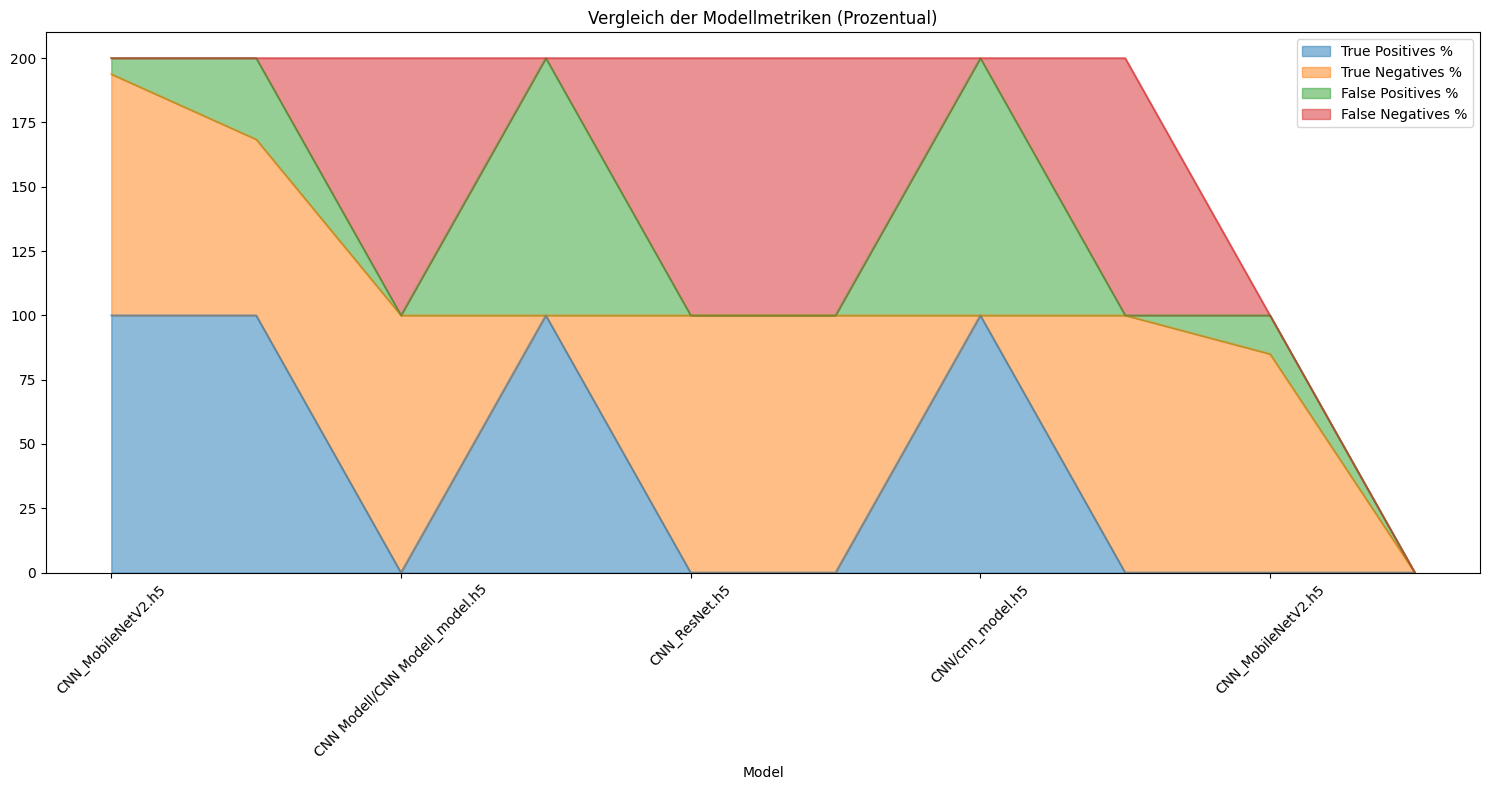

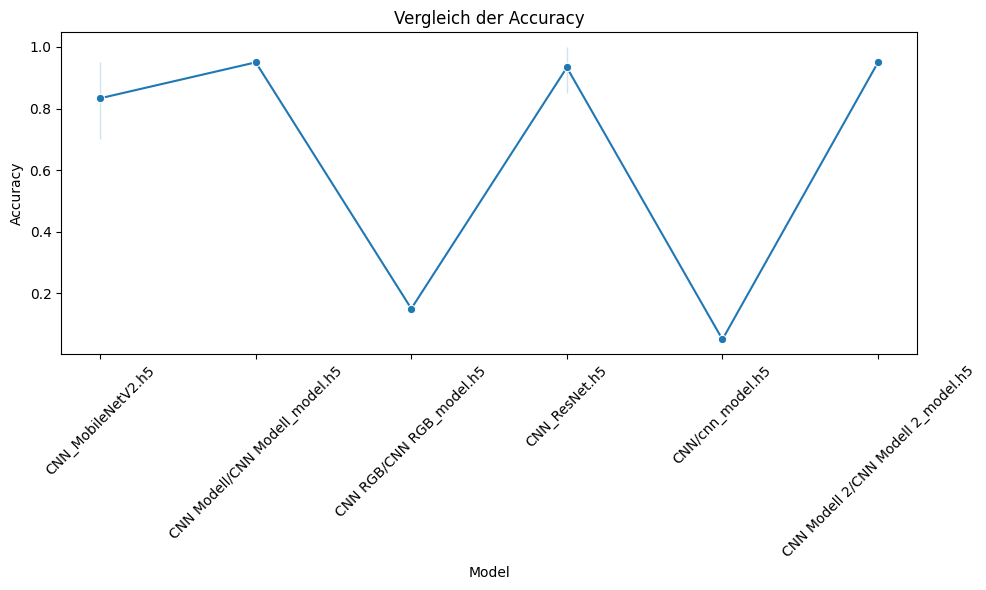

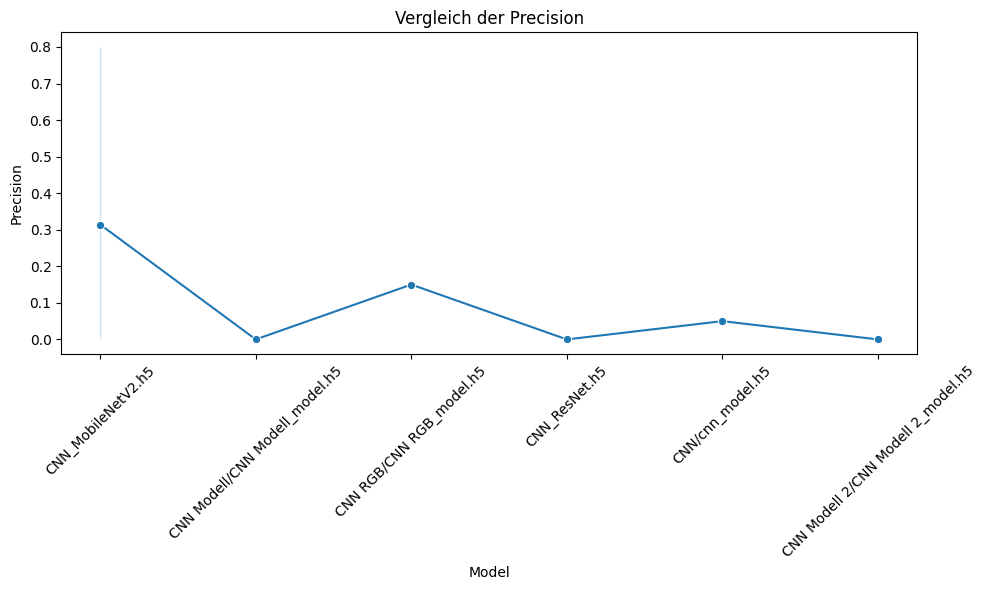

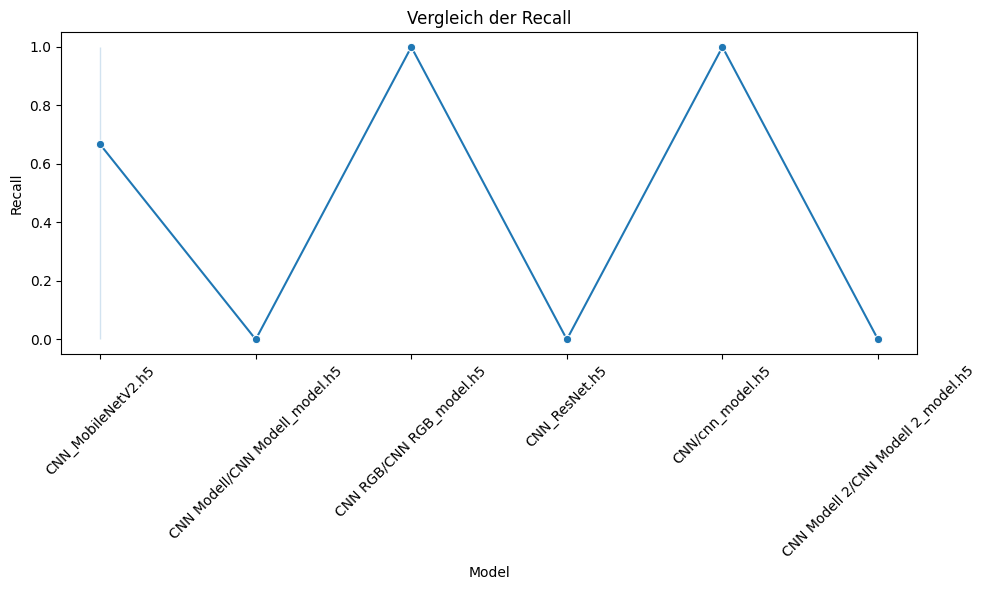

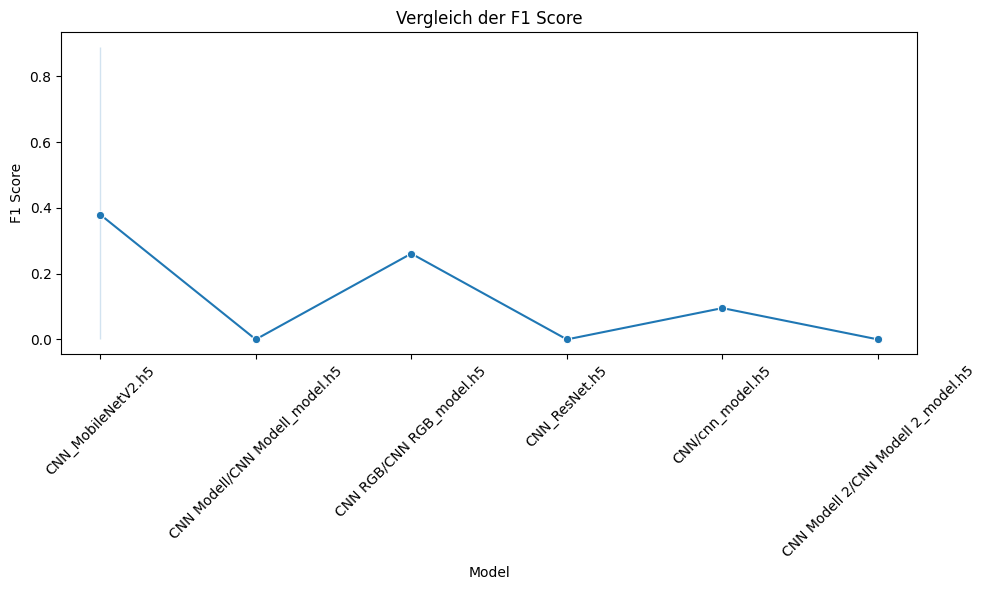

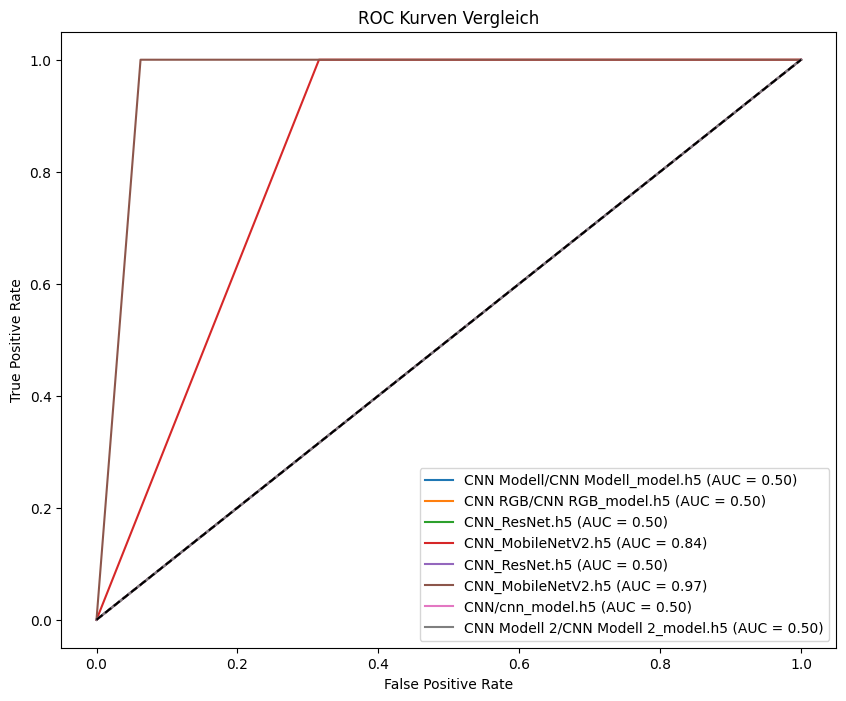

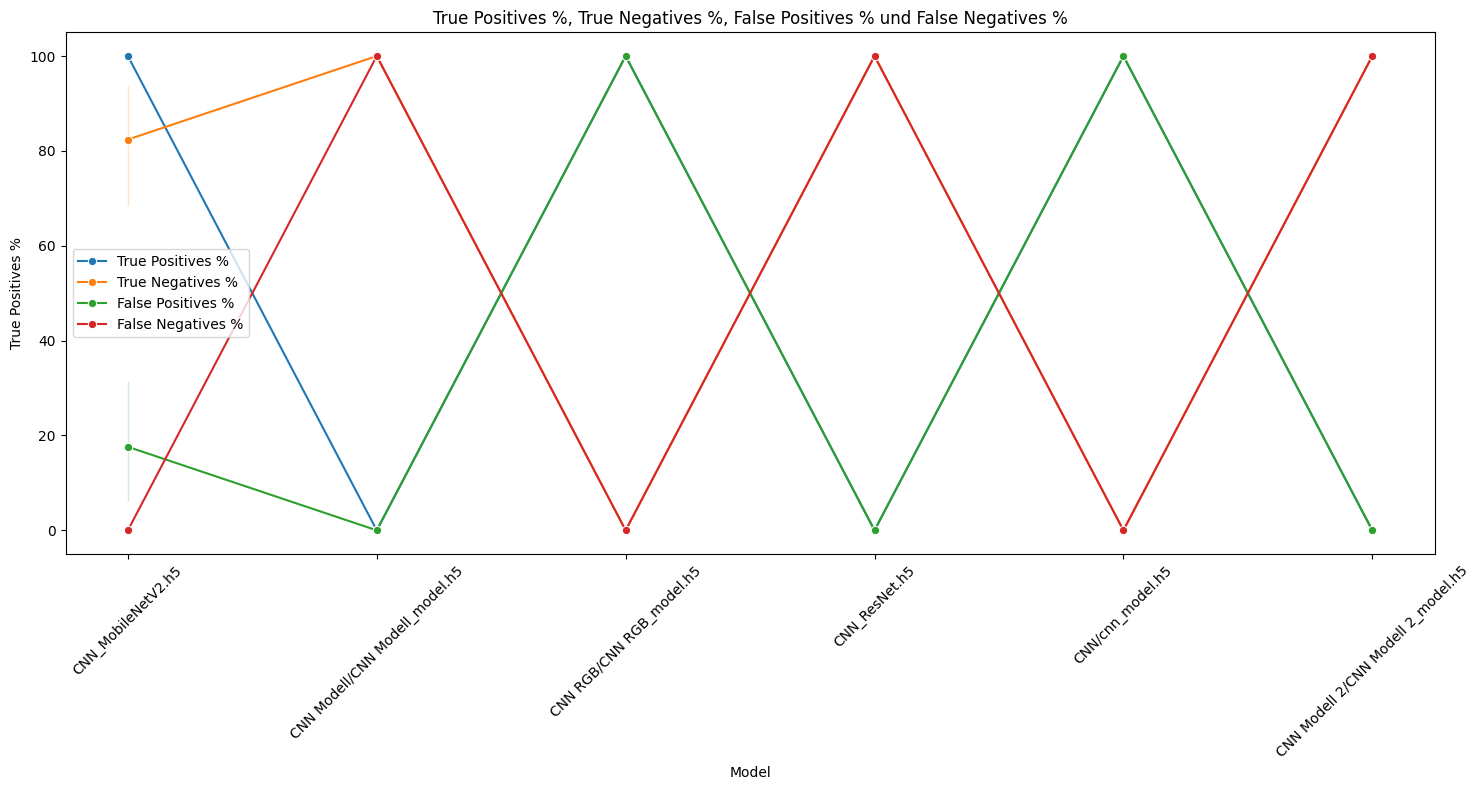

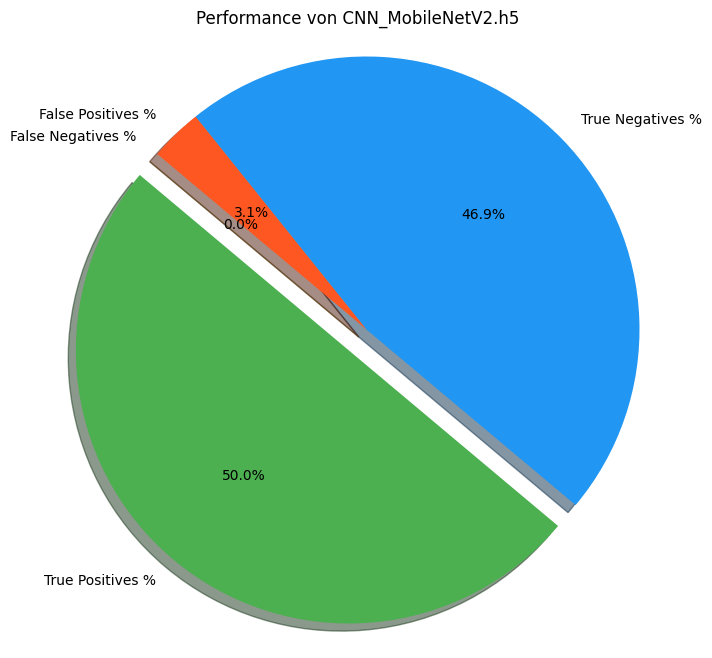

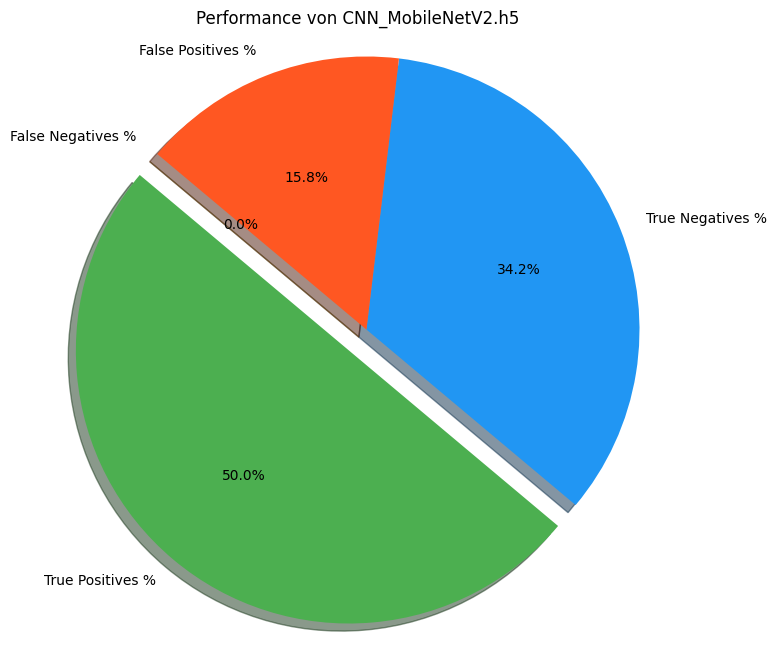

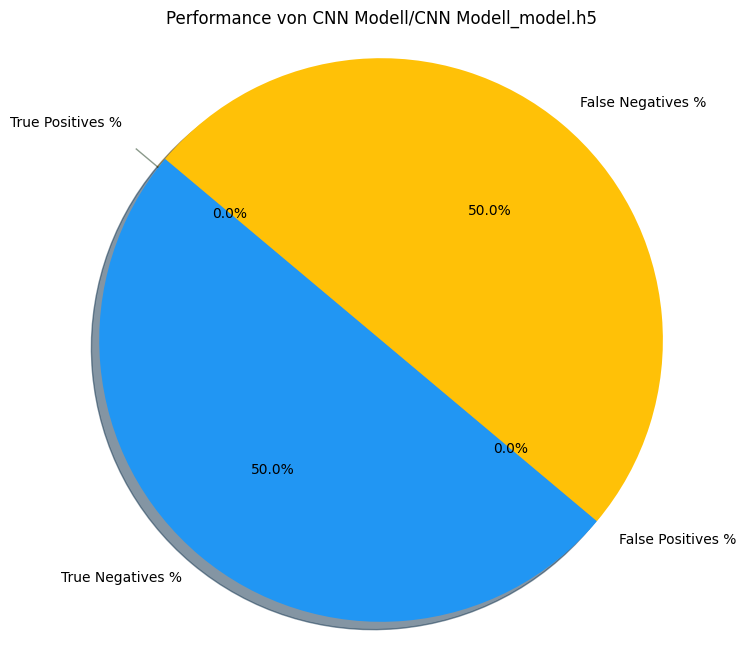

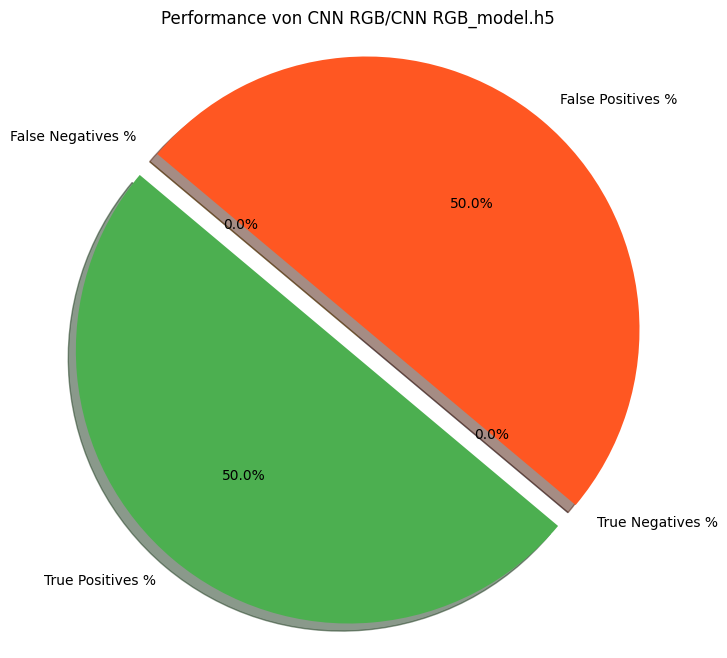

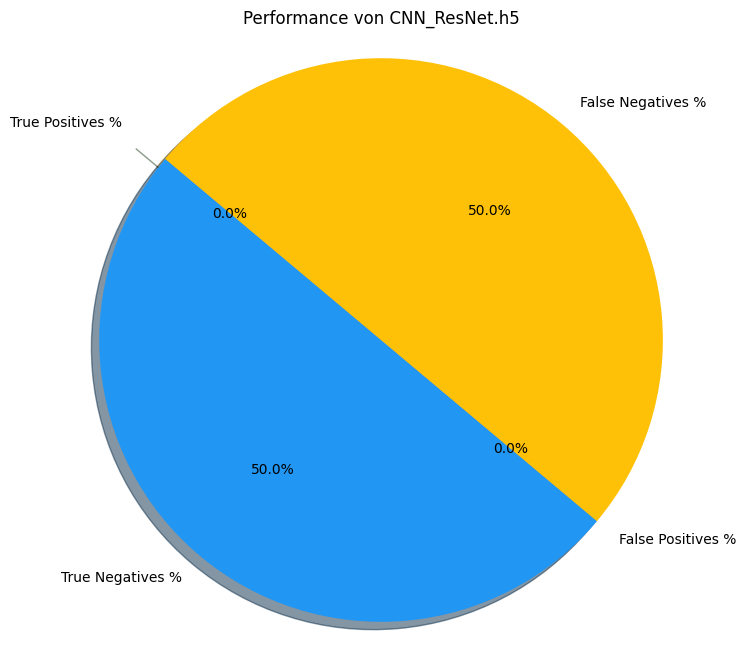

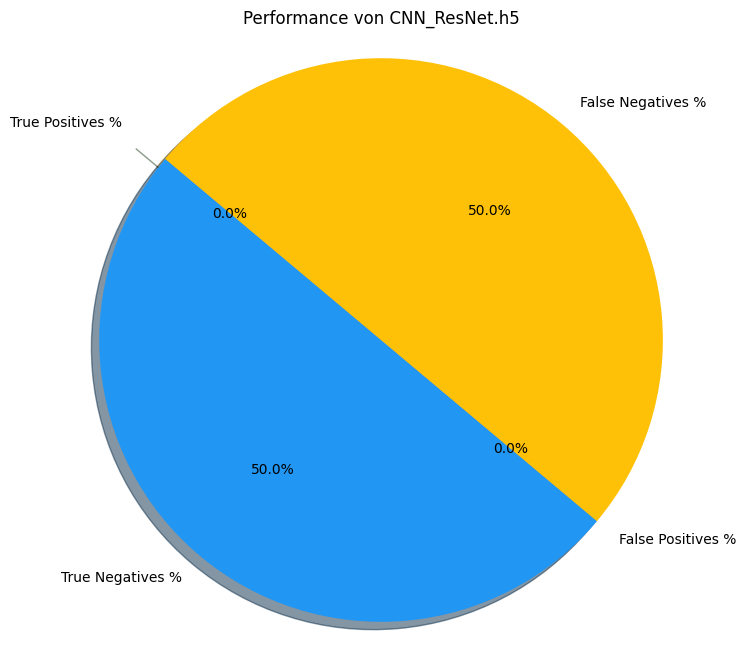

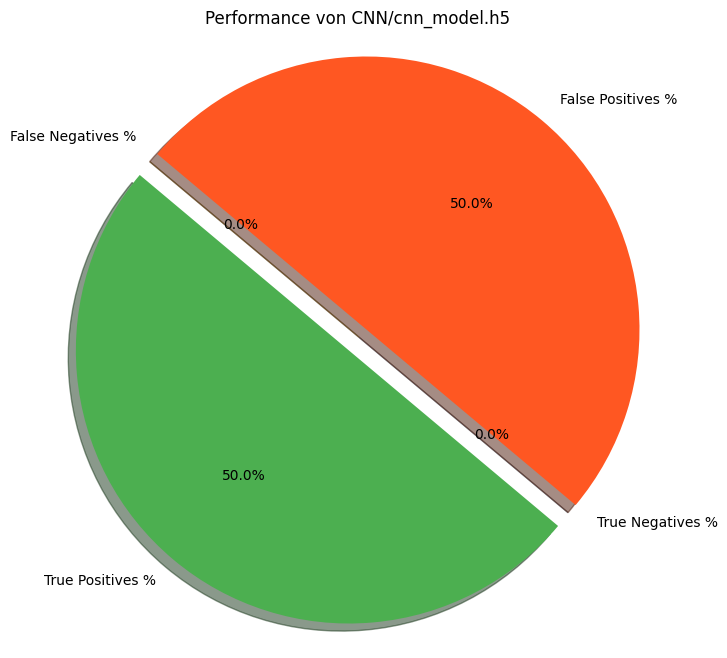

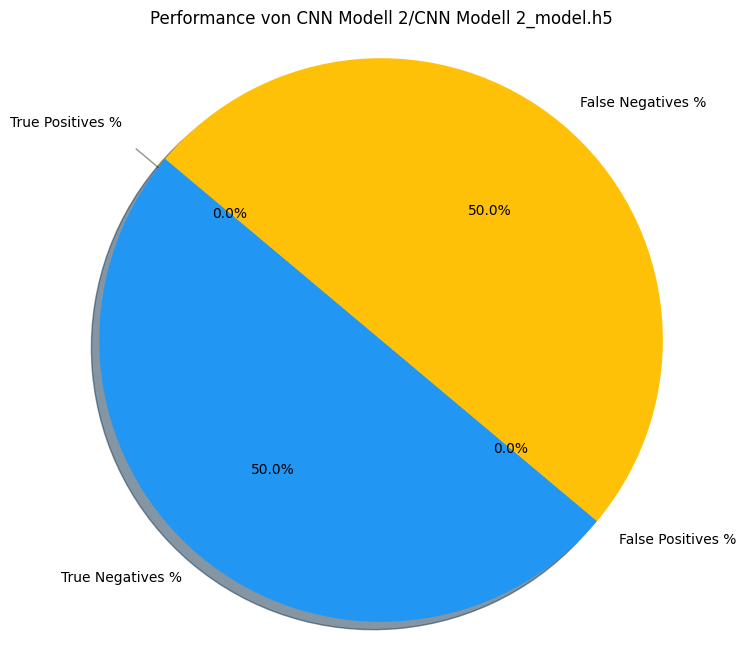

Ungültige Werte für Modell CNN_MobileNetV2.h5: [nan, 85.0, 15.0, nan]
Ungültige Werte für Modell CNN_ResNet.h5: [nan, nan, nan, nan]

Zusammenfassende Statistiken:
                                Model  Accuracy  Precision  Recall  F1 Score  True Positives  True Negatives  False Positives  False Negatives  True Positives %  True Negatives %  False Positives %  False Negatives %      Score
6                  CNN_MobileNetV2.h5      0.95   0.800000     1.0  0.888889               4              15                1                0             100.0         93.750000           6.250000                0.0  76.875000
3                  CNN_MobileNetV2.h5      0.70   0.142857     1.0  0.250000               1              13                6                0             100.0         68.421053          31.578947                0.0  64.210526
0      CNN Modell/CNN Modell_model.h5      0.95   0.000000     0.0  0.000000               0              19                0                1          

In [29]:
def main():
    print("GPU-Setup...")
    n_gpus = setup_gpus()
    
    print("Lade Modelle...")
    models = load_all_models()
    
    print("Bereite Evaluierung vor...")
    results = []
    errors = []
    batch_size = 20
    
    for model_idx, (model_name, (model, model_type)) in enumerate(models.items()):
        print(f"\nEvaluiere {model_name}...")
        gpu_id = model_idx % n_gpus
        torch.cuda.set_device(gpu_id)
        
        handle = nvidia_smi.nvmlDeviceGetHandleByIndex(gpu_id)
        info = nvidia_smi.nvmlDeviceGetMemoryInfo(handle)
        print(f"Vor Modell Laden - GPU {gpu_id} Speicher: {info.free/1024**2:.2f} MB frei")
        
        if hasattr(model, 'to'):
            model.to(f'cuda:{gpu_id}')
        
        info = nvidia_smi.nvmlDeviceGetMemoryInfo(handle)
        print(f"Nach Modell Laden - GPU {gpu_id} Speicher: {info.free/1024**2:.2f} MB frei")
        
        batch_results = []
        
        test_data = load_test_data(user_samples=20, other_samples=20)
        samples = test_data['sampleData'].tolist()
        y_test = (test_data['username'] == 'benutzername_1').astype(int).values
        
        try:
            if "Grey" in model_name:
                target_size = (64, 64)
                color_mode = 'grey'
            elif "224" in model_name or "ResNet" in model_name or "MobileNetV2" in model_name:
                target_size = (224, 224)
                color_mode = 'rgb'
            else:
                target_size = (64, 64)
                color_mode = 'rgb'
            
            X_test = process_batch_gpu(samples, batch_size=batch_size, gpu_id=gpu_id, target_size=target_size, color_mode=color_mode)

            result = evaluate_model(model, model_type, X_test, y_test, model_name, gpu_id)
            if result is not None:
                results.append(result)

        except Exception as e:
            print(f"Fehler bei der Verarbeitung von {model_name}: {e}")
            errors.append((model_name, str(e)))
            continue

        if hasattr(model, 'cpu'):
            model.cpu()
        del model
        torch.cuda.empty_cache()
        gc.collect()

        info = nvidia_smi.nvmlDeviceGetMemoryInfo(handle)
        print(f"Nach Evaluierung - GPU {gpu_id} Speicher: {info.free/1024**2:.2f} MB frei")

    if results:
        print("Erstelle Visualisierungen...")
        metrics_df = visualize_results(results)

        print("\nZusammenfassende Statistiken:")
        print(metrics_df.to_string())

        metrics_df.to_csv('Evaluierungsergebnisse/metrics.csv')
        print("\nEvaluierung abgeschlossen.")
        
        print("Ergebnisse:")
        print_results(results)
        
        print("Bewertung der Modelle:")
        evaluate_models(metrics_df)
    else:
        print("Keine Ergebnisse zur Visualisierung vorhanden.")

    if errors:
        print("\nFehler bei der Evaluierung folgender Modelle:")
        for model_name, error in errors:
            print(f"{model_name}: {error}")

    nvidia_smi.nvmlShutdown()

if __name__ == "__main__":
    main()

In [ ]:
def test_models_against_samples(models, user_samples=5, other_samples=5):
    print("Lade Testdaten für alle Nutzer...")
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()

    # Lade 5 Samples von Benutzer 1
    user_samples_cursor = db['canvassamples'].aggregate([
        {'$match': {'username': 'benutzername_1'}},
        {'$sample': {'size': user_samples}}
    ])
    user_samples_df = pd.DataFrame(list(user_samples_cursor))

    # Lade 5 Samples von anderen Nutzern
    other_samples_cursor = db['canvassamples'].aggregate([
        {'$match': {'username': {'$ne': 'benutzername_1'}}},
        {'$sample': {'size': other_samples}}
    ])
    other_samples_df = pd.DataFrame(list(other_samples_cursor))

    # Kombiniere die Samples
    test_samples_df = pd.concat([user_samples_df, other_samples_df])

    # Lade die Fingerprint-Daten
    fingerprint_ids = test_samples_df['fingerprintId'].unique().tolist()
    fingerprints_cursor = db['fingerprints'].find({'_id': {'$in': fingerprint_ids}}, {'_id': 1, 'username': 1})
    fingerprints_df = pd.DataFrame(list(fingerprints_cursor))

    # Verbinde die Samples mit den Fingerprint-Daten
    final_df = pd.merge(
        test_samples_df,
        fingerprints_df,
        left_on='fingerprintId',
        right_on='_id',
        suffixes=('_sample', '_fingerprint')
    )

    results = []

    for model_name, (model, model_type) in models.items():
        print(f"\nTesten des Modells: {model_name}")
        gpu_id = 0  # Verwende GPU 0 für alle Tests
        torch.cuda.set_device(gpu_id)

        if hasattr(model, 'to'):
            model.to(f'cuda:{gpu_id}')

        samples = final_df['sampleData'].tolist()
        y_true = (final_df['username_fingerprint'] == 'benutzername_1').astype(int).values

        if "Grey" in model_name:
            target_size = (64, 64)
            color_mode = 'grey'
        elif "224" in model_name or "ResNet" in model_name or "MobileNetV2" in model_name:
            target_size = (224, 224)
            color_mode = 'rgb'
        else:
            target_size = (64, 64)
            color_mode = 'rgb'

        X_test = process_batch_gpu(samples, batch_size=5, gpu_id=gpu_id, target_size=target_size, color_mode=color_mode)

        y_pred = model.predict(X_test)
        if y_pred.shape[1] > 1:
            y_pred = np.argmax(y_pred, axis=1)
        else:
            y_pred = (y_pred > 0.5).astype(int).flatten()

        for i, sample in enumerate(samples):
            results.append({
                'Model': shorten_model_name(model_name),
                'Sample': i,
                'True Label': 'benutzername_1' if y_true[i] == 1 else 'other',
                'Predicted Label': 'benutzername_1' if y_pred[i] == 1 else 'other'
            })

        if hasattr(model, 'cpu'):
            model.cpu()
        del model
        torch.cuda.empty_cache()
        gc.collect()

    return pd.DataFrame(results)

In [ ]:
def visualize_sample_results(results_df, output_dir="Evaluierungsergebnisse"):
    os.makedirs(output_dir, exist_ok=True)

    plt.figure(figsize=(15, 8))
    sns.scatterplot(data=results_df, x='Sample', y='Model', hue='True Label', style='Predicted Label', s=100)
    plt.title('Testergebnisse der Modelle gegen Samples von verschiedenen Nutzern')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'sample_results.png'))
    plt.show()
    plt.close()

In [37]:
if __name__ == "__main__":

    
    print("Teste Modelle gegen Samples von verschiedenen Nutzern...")
    models = load_all_models()  # Stelle sicher, dass models definiert ist
    sample_results_df = test_models_against_samples(models)
    visualize_sample_results(sample_results_df)

Teste Modelle gegen Samples von verschiedenen Nutzern...

Lade alle CNN-Modelle aus dem Verzeichnis: Modelle
  Modell geladen: CNN Modell/CNN Modell_cnn_model.h5
  Modell geladen: CNN RGB/CNN RGB_cnn_model.h5
  Modell geladen: CNN_Negative/model_experiment_2_ResNet.h5
  Modell geladen: CNN_Negative/model_experiment_3_MobileNetV2.h5
  Modell geladen: CNN_Negative/model_experiment_7_CNN.h5
  Modell geladen: CNN_Negative/model_experiment_1_CNN.h5
  Modell geladen: CNN_Negative/model_experiment_4_CNN.h5
  Modell geladen: CNN_Negative/model_experiment_6_MobileNetV2.h5
  Modell geladen: CNN_Negative/model_experiment_8_ResNet.h5
  Modell geladen: CNN_Negative/model_experiment_10_CNN.h5
  Modell geladen: CNN_Negative/model_experiment_9_MobileNetV2.h5
  Modell geladen: CNN_Negative/model_experiment_5_ResNet.h5
  Modell geladen: CNN Grey/CNN Grey_cnn_model.h5
  Modell geladen: CNN/cnn_model.h5
  Modell geladen: Autoencoder_CNN/autoencoder_model.h5
  Modell geladen: CNN Modell 2/CNN Modell 2_cnn_

KeyError: 'username_fingerprint'